# Length of Stay Patterns in a Synthetic Clinical Dataset
**Portfolio Project 1 | Descriptive Analytics**

## Overview
This project analyses hospital encounter length-of-stay (LOS) patterns
using a synthetic dataset of 100,000 encounter records.
The analysis is purely descriptive — no machine learning or prediction.

## Research Questions
1. How is encounter length of stay distributed across the dataset?
2. Does condition burden (number of comorbidities) drive longer stays?
3. Do facilities differ in average length of stay?

## Dataset
Synthetic clinical dataset — `Length_of_Stay_Database.csv`.
Place the file in a `data/` folder at the same level as this notebook
before running.

## Dependencies
Python 3.x | pandas | numpy | matplotlib | seaborn | scipy

Install with:
    pip install pandas numpy matplotlib seaborn scipy

In [ ]:
#Section 1: SETUP AND DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
df_raw = pd.read_csv('data/Length_of_Stay_Database.csv')

## Section 2: Data Validation

Checks performed:
- Null values across all columns
- Duplicate encounter IDs (`eid`)
- Fully duplicated rows
- LOS cross-verification: recalculate from `vdate` / `discharged`
  and confirm it matches the provided `lengthofstay` column
- LOS range check (min / max / zero-or-negative values)
- `rcount` value distribution (raw, before encoding)

`los_calculated` is added to a temporary validation frame (`df_check`)
only — it is NOT carried into the main working dataframe (`df_prep`).

In [ ]:
#Section 2: Data Validation
#Check null values, duplicates, verify LOS against dates, recount inspections
print(f"Null values per column:{df_raw.isnull().sum().sum()}")
print(f"Duplicate eids:{df_raw['eid'].duplicated().sum()}")
print(f"Fully duplicated rows:{df_raw.duplicated().sum()}")

df_check = df_raw.copy()
df_check['vdate'] = pd.to_datetime(df_check['vdate'])
df_check['discharged'] = pd.to_datetime(df_check['discharged'])
df_check['los_calculated'] = (df_check['discharged'] - df_check['vdate']).dt.days
match = (df_check['los_calculated'] == df_check['lengthofstay']).value_counts()
print(f"LOS verification (calculated vs provided): {match}")
print(f"lengthofstay range: {df_raw['lengthofstay'].min()} to {df_raw['lengthofstay'].max()} days")
print(f"Zero or negative values: {(df_raw['lengthofstay'] <= 0).sum()}")

print(f"rcount value distribution: {df_raw['rcount'].value_counts().sort_index()}")





## Section 3: Data Preparation

Steps:
1. Copy raw frame → `df_prep` (original is preserved as `df_raw`).
2. Parse `vdate` and `discharged` as datetime.
3. Extract `admission_month` from `vdate`.
4. Encode `rcount`: replace `"5+"` with `5`, cast to numeric.
   *Reason:* `"5+"` prevents numeric operations; `5` is a conservative
   floor and is defensible in interviews.
5. Create `prior_visit_flag` (binary): 1 if `rcount > 0`, else 0.
   *Limitation:* This is a proxy — the dataset has no patient identifier
   so true readmission rate cannot be computed.
6. Count comorbidities → `num_conditions` (sum of 11 binary flags).
7. Bin comorbidities → `burden_group` (display-only ordered categorical).
   *Reason for strings:* supports a `"3+"` bucket and guarantees
   chart ordering via `pd.Categorical`.

In [ ]:
#Section 3: Data Preparation
#Converting dates, handle rcounts, prior visit flag, burden group for vis., final shape
df_prep = df_raw.copy()

df_prep['vdate'] = pd.to_datetime(df_prep['vdate'])
df_prep['discharged'] = pd.to_datetime(df_prep['discharged'])
df_prep['admission_month'] = df_prep['vdate'].dt.month

df_prep['rcount'] = df_prep['rcount'].replace('5+','5')
df_prep['rcount'] = pd.to_numeric(df_prep['rcount'], errors = 'coerce')

df_prep['prior_visit_flag'] = (df_prep['rcount'] > 0).astype(int)
print(f"Prior visit flag rate: {df_prep['prior_visit_flag'].mean()*100:.1f}%")

condition_columns = [
    'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor',
    'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo'
    ]
df_prep['num_conditions'] = df_prep[condition_columns].sum(axis=1)
print(df_prep['num_conditions'].value_counts().sort_index())

df_prep['burden_group'] = pd.cut(df_prep['num_conditions'], bins=[-1,0,1,2,11], labels = ['0 conditions', '1 conditions', '2 conditions', '3+ conditions'])

print(f'Final dataset shape: {df_prep.shape}')
print(f'Total encounters: {len(df_prep):,}')
print()
print('Derived columns added (3 analytical + 1 display-only = 4 total):')
print('  Analytical:')
print('    1. admission_month    — extracted from vdate')
print('    2. prior_visit_flag   — rcount > 0 proxy')
print('    3. num_conditions     — sum of 11 binary comorbidity flags')
print('  Display-only helpers:')
print('    4. burden_group         — ordered categorical version of rcount')



## Section 4: Exploratory Data Analysis

Summaries produced:
- LOS distribution (mean, median, SD, min, max, tail percentages)
- Condition burden overview (mean conditions, 0-condition and 3+
  condition encounter counts, per-condition prevalence rates)
- Facility-level LOS summary (encounter count, mean, median, SD)

In [ ]:
#Section 4: Exploratory Data Analysis
#LOS Distribution, condition burden overview, facility overview,
print("Length of Stay Summary")
print(f"Mean: {df_prep['lengthofstay'].mean():.1f} days")
print(f"Median: {df_prep['lengthofstay'].median():.1f} days")
print(f"STD Dev: {df_prep['lengthofstay'].std():.1f} days")
print(f"Min: {df_prep['lengthofstay'].min()} days")
print(f"Max: {df_prep['lengthofstay'].max()} days")
print(f"% encounters LOS > 7: {(df_prep['lengthofstay'] > 7).mean()*100:.1f}%")
print(f"% encounters LOS <= 3: {(df_prep['lengthofstay'] <= 3).mean()*100:.1f}%")

print('\nCondition Burden')
print(f"Mean conditions per encounter: {df_prep['num_conditions'].mean():.2f}")
print(f"Encounters with 0 conditions: {(df_prep['num_conditions'] == 0).sum():,}" f"({(df_prep['num_conditions'] == 0).mean()*100:.1f}%)")
print(f"Encounters with 3+ conditions: {(df_prep['num_conditions'] >= 3).sum():,}" f"({(df_prep['num_conditions'] >= 3).mean()*100:.1f}%)")
print(f"\nCondition prevelance (% of encounters):")
for col in condition_columns:
  print(f"{col:<35}{df_prep[col].mean()*100:.1f}%")

facility_summary = df_prep.groupby('facid').agg(
    encounters=('eid', 'count'),
    mean_los=('lengthofstay', 'mean'),
    median_los=('lengthofstay', 'median'),
    std_los=('lengthofstay', 'std')
).round(2)
print(facility_summary.sort_values('mean_los', ascending=False))

## Section 5: Statistical Analysis

Tests performed:
1. **95 % CI for mean LOS** — manual calculation using z = 1.96
   (sample size n = 100,000 makes the normal approximation valid).
2. **Welch's independent-samples t-test** — high-burden (≥ 3
   conditions) vs low-burden (< 3 conditions) encounters.
   *Note:* p-value displays as 0.0 due to floating-point underflow
   at n = 100,000.  Effect size (Cohen's d) is the meaningful measure.
3. **Pearson and Spearman correlations** — `num_conditions` vs LOS.
  Similar values confirm the linear assumption is reasonable.

In [ ]:
#Section 5: Statistical Analysis
#CI for mean LOS, hypothesis testing (condition burden v los), correlation analysis
#Confidence Interval for Mean LOS
mean_los = df_prep['lengthofstay'].mean()
std_error = df_prep['lengthofstay'].std()/np.sqrt(len(df_prep))
ci_lower = mean_los - 1.96*std_error
ci_upper = mean_los + 1.96*std_error

print(f"Mean LOS: {mean_los:.2f} days")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}] days")

# Hypothesis Test: Condition Burden vs LOS
high_burden = df_prep[df_prep['num_conditions'] >= 3]['lengthofstay']
low_burden = df_prep[df_prep['num_conditions'] < 3]['lengthofstay']

t_stat, p_value = stats.ttest_ind(high_burden, low_burden, equal_var=False)

pooled_std = np.sqrt((high_burden.std()**2 + low_burden.std()**2)/2)
cohens_d = (high_burden.mean() - low_burden.mean())/pooled_std

print(f"High-burden (+3): n={len(high_burden):,}, mean = {high_burden.mean():.2f} days")
print(f"Low-burden (<3): n={len(low_burden):,}, mean = {low_burden.mean():.2f} days")
print(f"Difference: {high_burden.mean() - low_burden.mean():.2f} days")
print(f"t-statistic: {t_stat:.2f}")
print(f"p_value: {p_value:.4e}")
print(f"Significant: {'Yes (p<0.05)' if p_value < 0.05 else 'No'}")
print(f"Cohen d: {cohens_d:.3f} (< 0.2 Low | 0.5 Medium | 0.8 Large)")
print(f"Note: P-value displays as 0.0 due to floating-point underflow at n=100,000. Effect size (Cohen's d) is the meaningful measure here.")

#Correlation Analysis
r_cond, p_cond = stats.pearsonr(df_prep['num_conditions'], df_prep['lengthofstay'])
print(f"Pearson: num_conditions vs LOS: r = {r_cond:.3f}, p = {p_cond:.4e}")

rho_cond, p_spear = stats.spearmanr(df_prep['num_conditions'], df_prep['lengthofstay'])
print(f"Spearman: num_conditions vs LOS: rho = {rho_cond:.3f}, p = {p_spear:.4e}")
print("If Pearson and Spearman are similar, the linear assumption holds.")

## Section 6: Visualisations

Four chart pairs are produced and saved:

| File                          | Contents                                  |
|-------------------------------|-------------------------------------------|
| chart1_los_distribution.png   | LOS histogram + burden boxplot            |
| chart2_facility_comparison.png| Mean LOS by facility with ±1 SD           |
| chart3_comorbidity.png        | Mean LOS and prevalence per comorbidity   |
| chart4_condition_burden.png   | Mean LOS + prior-visit rate by burden     |



**Chart 1 — LOS Distribution + Burden Boxplot**
Expect right skew: most encounters are short stays, with a long tail of complex cases. Mean and median should be close but not identical. The boxplot tests whether burden tiers produce visibly different LOS distributions — if the medians step up across tiers, that supports the hypothesis in Section 5.

**Chart 2 — Facility Comparison**
Checks whether mean LOS varies across facilities. Large differences would suggest case-mix differences between sites, not performance variation — the dataset has no acuity adjustment so no causal claim can be made.

**Chart 3 — Comorbidity Prevalence vs Mean LOS**
Two panels side by side: which conditions extend stays, and how common are they. The interesting question is whether high-LOS conditions are also high-prevalence — if they are, they drive a disproportionate share of total bed-days.

**Chart 4 — Condition Burden: LOS and Prior Visit Rate**
Tests whether encounters with more comorbidities also have higher prior-visit rates. If both LOS and prior-visit flag rise together across burden tiers, that suggests a consistently higher-complexity patient profile — though note `prior_visit_flag` is a proxy, not a confirmed readmission metric.

Charts are saved to an `outputs/` folder (created automatically).


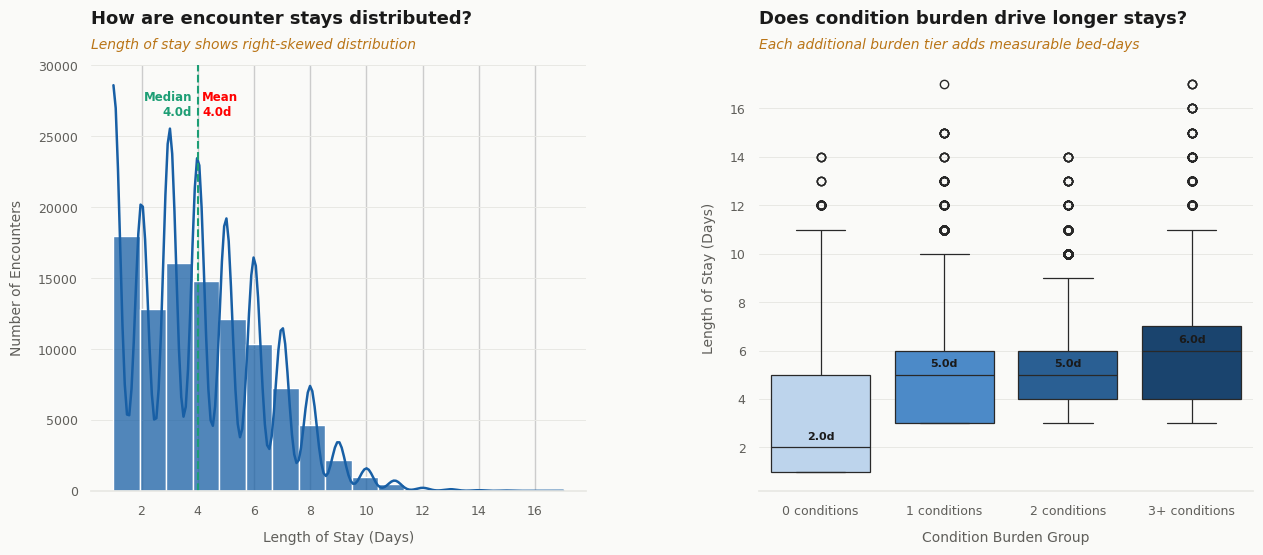

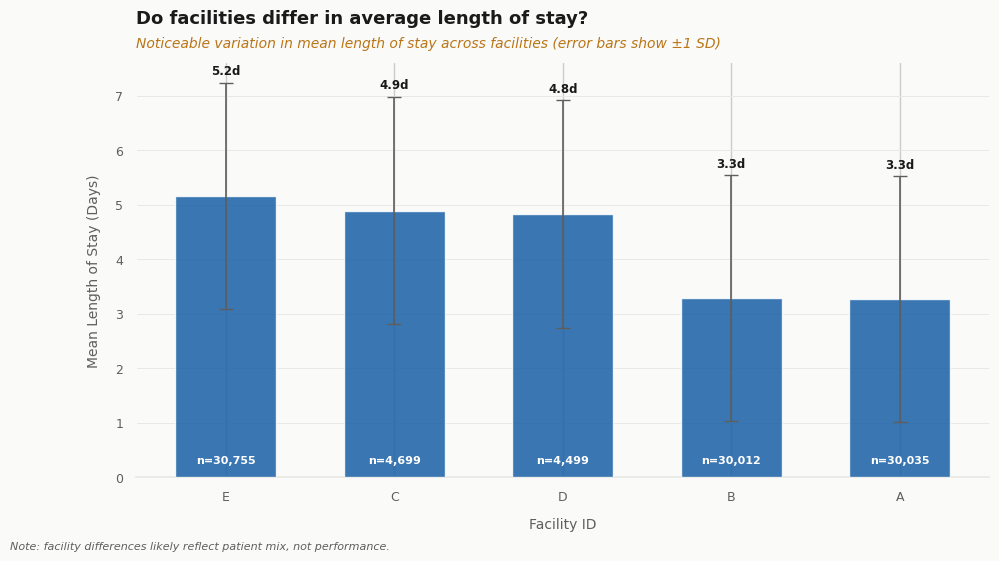

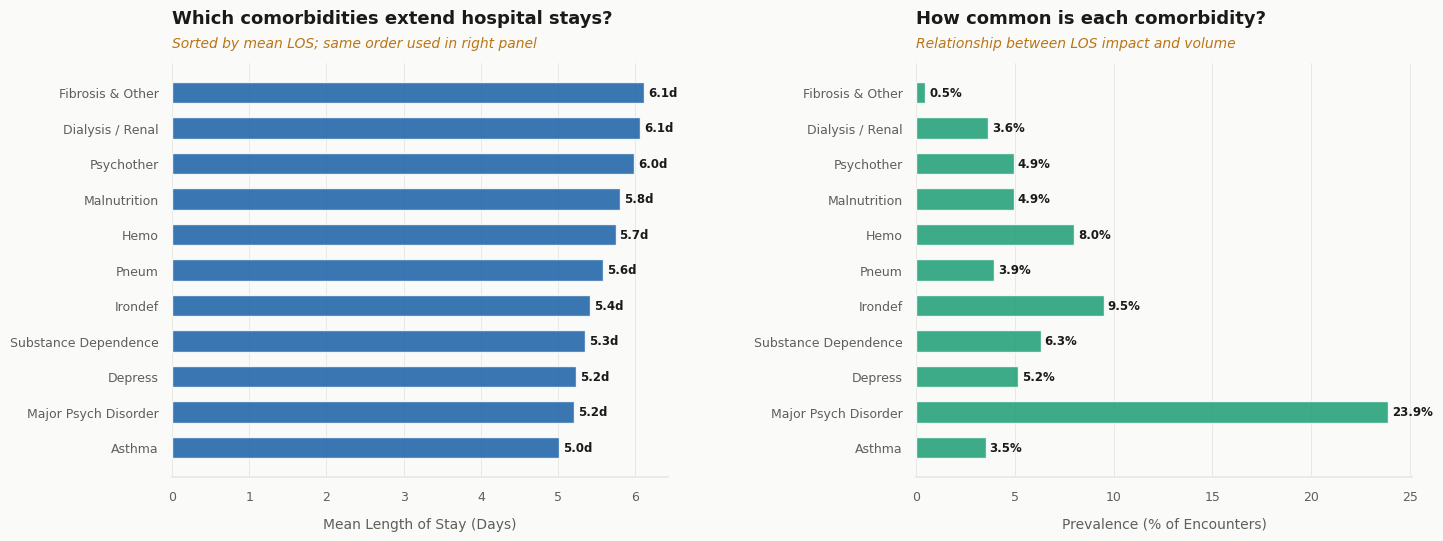

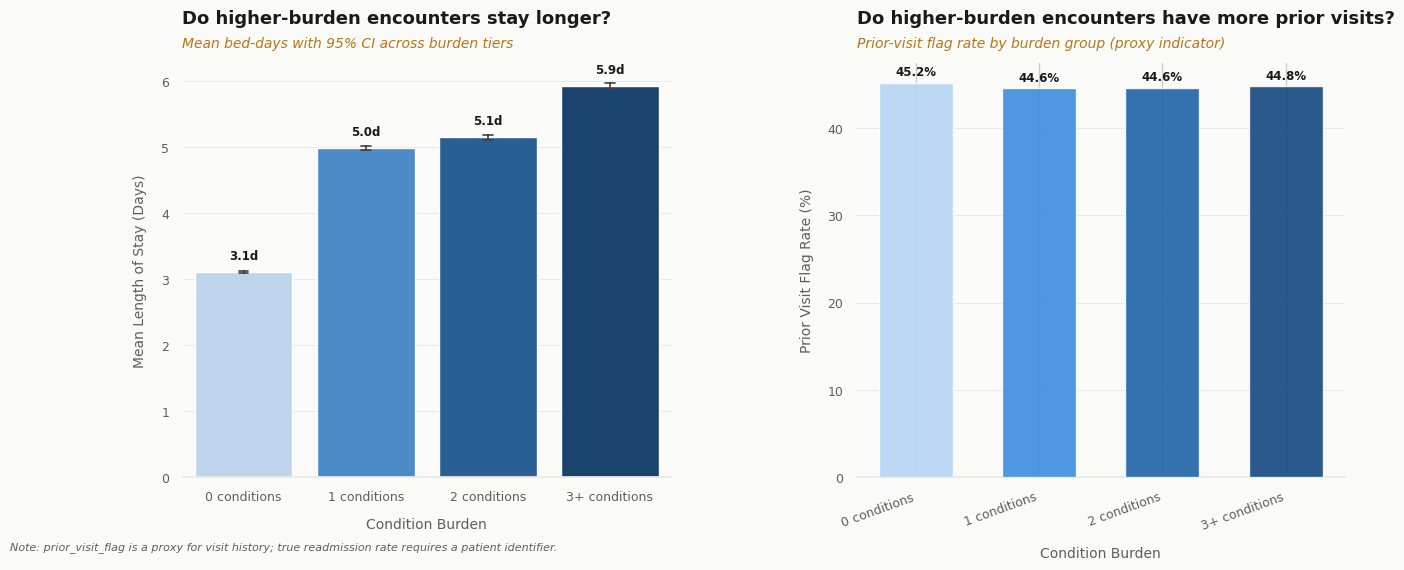

In [35]:
# Section 6: Visualizations
import os
os.makedirs('outputs', exist_ok=True)

#Colors
PRIMARY   = '#185FA5'   # deep blue
ACCENT    = '#1D9E75'   # teal
CALLOUT   = '#BA7517'   # amber — used only for insight subtitles
TEXT      = '#1A1A1A'
MUTED     = '#5F5E5A'
GRID      = '#E8E8E4'
BG        = '#FAFAF8'

# Light-to-dark blue for burden groups
BURDEN_PALETTE = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
burden_order   = sorted(df_prep['burden_group'].unique())


def style(ax, title, subtitle, xlabel, ylabel):
    """One call sets title, insight subtitle, axis labels, grid, spines."""
    ax.text(0, 1.13, title,    transform=ax.transAxes, fontsize=13,
            fontweight='bold', color=TEXT, va='top', ha='left')
    ax.text(0, 1.065, subtitle, transform=ax.transAxes, fontsize=10,
            color=CALLOUT, va='top', ha='left', style='italic')
    ax.set_xlabel(xlabel, fontsize=10, color=MUTED, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=10, color=MUTED, labelpad=10)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.set_facecolor(BG)


#C1: LOS Distribution + Burden Boxplot
mean_los   = df_prep['lengthofstay'].mean()
median_los = df_prep['lengthofstay'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0.35, top=0.82)

sns.histplot(df_prep['lengthofstay'], bins=17, kde=True,
             color=PRIMARY, alpha=0.75, line_kws={'linewidth': 1.8}, ax=axes[0])
axes[0].axvline(median_los, color=ACCENT,  linewidth=1.5, linestyle='--')
axes[0].text(median_los - 0.2, axes[0].get_ylim()[1] * 0.88,
             f'Median\n{median_los:.1f}d', fontsize=8.5, color=ACCENT,  fontweight='bold', ha='right')
axes[0].text(mean_los + 0.15, axes[0].get_ylim()[1] * 0.88,
             f'Mean\n{mean_los:.1f}d', fontsize=8.5, color='red',
             fontweight='bold', ha='left')
style(axes[0],
      'How are encounter stays distributed?',
      f'Length of stay shows right-skewed distribution',
      'Length of Stay (Days)', 'Number of Encounters')

sns.boxplot(x='burden_group', y='lengthofstay', data=df_prep,
            order=burden_order, palette=BURDEN_PALETTE,
            hue='burden_group', hue_order=burden_order, legend=False,
            linewidth=0.9, ax=axes[1])
for i, grp in enumerate(burden_order):
    med = df_prep[df_prep['burden_group'] == grp]['lengthofstay'].median()
    axes[1].text(i, med + 0.25, f'{med:.1f}d',
                 ha='center', va='bottom', fontsize=8, color=TEXT, fontweight='bold')
style(axes[1],
      'Does condition burden drive longer stays?',
      'Each additional burden tier adds measurable bed-days',
      'Condition Burden Group', 'Length of Stay (Days)')

plt.savefig('outputs/chart1_los_distribution.png',  dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()


#C2: Facility Comparison
facility_stats = (df_prep.groupby('facid')
                  .agg(mean_los=('lengthofstay','mean'),
                       std_los=('lengthofstay','std'),
                       count=('eid','count'))
                  .reset_index()
                  .sort_values('mean_los', ascending=False))

high_fac = facility_stats.iloc[0]['facid']
low_fac  = facility_stats.iloc[-1]['facid']
gap      = facility_stats['mean_los'].max() - facility_stats['mean_los'].min()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(top=0.80)

ax.bar(range(len(facility_stats)), facility_stats['mean_los'],
       color=PRIMARY, alpha=0.85, zorder=3, width=0.6)
ax.errorbar(range(len(facility_stats)), facility_stats['mean_los'],
            yerr=facility_stats['std_los'],
            fmt='none', capsize=5, color=MUTED, linewidth=1.2, zorder=4)

for i, (_, row) in enumerate(facility_stats.iterrows()):
    ax.text(i, row['mean_los'] + row['std_los'] + 0.15,
            f"{row['mean_los']:.1f}d", ha='center', fontsize=8.5, color=TEXT, fontweight='bold')
    ax.text(i, 0.25, f"n={row['count']:,}",
            ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(range(len(facility_stats)))
ax.set_xticklabels(facility_stats['facid'])
style(ax,
      'Do facilities differ in average length of stay?',
      f'Noticeable variation in mean length of stay across facilities (error bars show ±1 SD)',
      'Facility ID', 'Mean Length of Stay (Days)')
fig.text(0.01, -0.01,
         'Note: facility differences likely reflect patient mix, not performance.',
         fontsize=8, color=MUTED, style='italic')

plt.savefig('outputs/chart2_facility_comparison.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()


#C3: Comorbidity Prevalence & Mean LOS
RENAME = {
    'dialysisrenalendstage':    'Dialysis / Renal',
    'psychologicaldisordermajor': 'Major Psych Disorder',
    'substancedependence':      'Substance Dependence',
    'fibrosisandother':         'Fibrosis & Other',
}

condition_stats = []
for col in condition_columns:          #existing condition_columns list
    subset = df_prep[df_prep[col] == 1]
    if len(subset) > 0:
        condition_stats.append({
            'condition':     RENAME.get(col, col.replace('_',' ').title()),
            'mean_los':      subset['lengthofstay'].mean(),
            'prevalence_pct': len(subset) / len(df_prep) * 100,
        })

cond_df = (pd.DataFrame(condition_stats)
             .sort_values('mean_los', ascending=True))   # ascending so longest is at top of hbar

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0.5, top=0.80)

axes[0].barh(cond_df['condition'], cond_df['mean_los'],
             color=PRIMARY, alpha=0.85, height=0.6)
for i, (_, row) in enumerate(cond_df.iterrows()):
    axes[0].text(row['mean_los'] + 0.05, i, f"{row['mean_los']:.1f}d",
                 va='center', fontsize=8.5, color=TEXT, fontweight='bold')
style(axes[0],
      'Which comorbidities extend hospital stays?',
      'Sorted by mean LOS; same order used in right panel',
      'Mean Length of Stay (Days)', '')
axes[0].xaxis.grid(True, color=GRID, linewidth=0.7)
axes[0].yaxis.grid(False)

axes[1].barh(cond_df['condition'], cond_df['prevalence_pct'],
             color=ACCENT, alpha=0.85, height=0.6)
for i, (_, row) in enumerate(cond_df.iterrows()):
    axes[1].text(row['prevalence_pct'] + 0.2, i, f"{row['prevalence_pct']:.1f}%",
                 va='center', fontsize=8.5, color=TEXT, fontweight='bold')
style(axes[1],
      'How common is each comorbidity?',
      'Relationship between LOS impact and volume',
      'Prevalence (% of Encounters)', '')
axes[1].xaxis.grid(True, color=GRID, linewidth=0.7)
axes[1].yaxis.grid(False)

plt.savefig('outputs/chart3_comorbidity.png',        dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()


#C4: Condition Burden — LOS & Prior Visit Rate
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0.38, top=0.80)

sns.barplot(x='burden_group', y='lengthofstay', data=df_prep,
            order=burden_order, errorbar=('ci', 95),
            palette=BURDEN_PALETTE, hue='burden_group',
            hue_order=burden_order, legend=False,
            capsize=0.08, err_kws={'linewidth': 1.2}, ax=axes[0])
for i, grp in enumerate(burden_order):
    val = df_prep[df_prep['burden_group'] == grp]['lengthofstay'].mean()
    axes[0].text(i, val + 0.15, f'{val:.1f}d',
                 ha='center', va='bottom', fontsize=8.5, color=TEXT, fontweight='bold')
style(axes[0],
      'Do higher-burden encounters stay longer?',
      'Mean bed-days with 95% CI across burden tiers',
      'Condition Burden', 'Mean Length of Stay (Days)')

burden_prior = (df_prep.groupby('burden_group', observed=True)['prior_visit_flag']
                .mean() * 100).reindex(burden_order)
axes[1].bar(range(len(burden_order)), burden_prior.values,
            color=BURDEN_PALETTE, alpha=0.88, width=0.6, zorder=3)
for i, val in enumerate(burden_prior.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=8.5, color=TEXT, fontweight='bold')
axes[1].set_xticks(range(len(burden_order)))
axes[1].set_xticklabels([str(b) for b in burden_order], rotation=20, ha='right')
style(axes[1],
      'Do higher-burden encounters have more prior visits?',
      'Prior-visit flag rate by burden group (proxy indicator)',
      'Condition Burden', 'Prior Visit Flag Rate (%)')
fig.text(0.01, -0.01,
         'Note: prior_visit_flag is a proxy for visit history; true readmission rate requires a patient identifier.',
         fontsize=8, color=MUTED, style='italic')

plt.savefig('outputs/chart4_condition_burden.png',   dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()





## Scope and Limitations

- **Descriptive only.** No predictive modelling is performed.
- **Synthetic data.** No patient identifier exists in the dataset,
  so true readmission rate cannot be calculated.
  `prior_visit_flag` is a proxy, not a readmission metric.
- **Outliers retained.** Long stays are clinically plausible events,
  not data errors, so no outlier removal was applied.
- **Condition scoring excluded.** Weighting comorbidities into a
  composite score would require arbitrary weights that are not
  defensible without domain knowledge.